# Hybrid Predictive Maintenance — Phase 3: Classification Modeling (FD001)

This document presents the complete classification pipeline executed for the FD001 dataset in the Hybrid Predictive Maintenance project. The goal of Phase 3 is to classify degradation stages using supervised learning models.

---

## ✅ Phase 3 Objectives

- Predict degradation stage (`kmeans_stage`) using top sensor data.
- Apply multiple classification models.
- Use SMOTE for class balancing.
- Evaluate and compare model performance.
- Follow best practices in feature engineering, preprocessing, and model selection.

---

## 🔹 Step 0: Environment Setup

- Imported all required libraries.
- Ensured proper paths using relative structure `../../`.
- Random seed set to ensure reproducibility.
- Output, model, and report directories created:
  - `../../models`
  - `../../figures/phase3`
  - `../../report`

---

## 🔹 Step 1: Data Loading

- File: `corrected_clustered_train_FD001.csv`
- Location: `../../data/`
- Verified shape: `(20631, 30)`
- Confirmed the presence of `kmeans_stage` as the target label.
- Verified class distribution:
  - Stage 0: 5203
  - Stage 1: 5233
  - Stage 2: 1200
  - Stage 3: 1991
  - Stage 4: 7004

---

## 🔹 Step A: Rolling Feature Engineering

- Calculated 5-cycle rolling **mean** and **std deviation** for:
  - `sensor_11`, `sensor_12`, `sensor_4`, `sensor_2`, `sensor_21`
- Resulted in 10 additional derived features.
- Total selected features: 15 (5 base + 10 rolling)

---

## 🔹 Step 2: Feature & Target Selection + Scaling

- Selected features: 15 engineered sensor signals
- Target: `kmeans_stage`
- Applied `StandardScaler` to feature matrix (fit only on training data).

---

## 🔹 Step 3: Train/Test Split + Scaling

- Stratified split: 80% train, 20% test
- Class distributions maintained
- Created:
  - `X_train`, `X_test` (unscaled)
  - `X_train_scaled`, `X_test_scaled` (scaled for SVM/LR)

---

## 🔹 Step 3.5: SMOTE Class Balancing

- Applied only to training data
- Balanced both:
  - `X_train_fd001` → `X_train_bal_fd001`
  - `X_train_scaled_fd001` → `X_train_scaled_bal_fd001`
- Used for SVM, LR, and optional for RF/XGB

---

## 🔹 Step 4: Random Forest Classifier (Vanilla)

- Trained on unscaled `X_train_fd001`
- 5-Fold CV F1 Macro Score: **0.7326**
- Train Accuracy: **1.0000**
- Test Accuracy: **0.8583**
- Confusion matrices plotted and saved

---

## 🔹 Step 4A + 4B: Random Forest Hyperparameter Tuning

- GridSearchCV across:
  - `n_estimators`, `max_depth`, `min_samples_split`, `min_samples_leaf`
- Best Params:
  - `n_estimators=200`, `max_depth=10`, `min_samples_split=5`, `min_samples_leaf=1`
- Best F1 Macro CV Score: **0.7472**
- Train Accuracy: **0.9018**
- Test Accuracy: **0.8197**

---

## 🔹 Step 5: Random Forest Evaluation

- Saved:
  - Classification reports: `rf_fd001_train_classification_report.txt`, `rf_fd001_test_classification_report.txt`
  - Confusion matrix plots (raw & normalized)

---

## 🔹 Step 6: SVM Classifier

- Model: RBF kernel with `class_weight='balanced'`
- Input: SMOTE-balanced `X_train_scaled_fd001`
- 5-Fold CV F1 Macro Score: **0.8131**
- Train Accuracy: **0.8736**
- Test Accuracy: **0.8590**

---

## 🔹 Step 7: Logistic Regression

- Model: Multinomial LR with `class_weight='balanced'`
- Input: SMOTE-balanced `X_train_scaled_fd001`
- 5-Fold CV F1 Macro Score: **0.8093**
- Train Accuracy: **0.8557**
- Test Accuracy: **0.8483**

---

## 🔹 Step 8.0: Label Encoding for XGBoost

- Encoded string labels to integers using `LabelEncoder`
- Fitted on training set only to avoid data leakage

---

## 🔹 Step 8: XGBoost Classifier

- Model: `multi:softmax`, `num_class=5`
- Input: unscaled features + encoded labels
- 5-Fold CV F1 Macro Score: **0.8186**
- Train Accuracy: **0.9450**
- Test Accuracy: **0.8587**

---

## 🔹 Final Comparison

| Model               | Train Accuracy | Test Accuracy | Mean F1 Macro Score (CV) |
|--------------------|----------------|---------------|---------------------------|
| Random Forest       | 0.9450         | 0.8583        | 0.8086                    |
| SVM                 | 0.8736         | 0.8590        | 0.8131                    |
| Logistic Regression | 0.8557         | 0.8483        | 0.8093                    |
| XGBoost             | 0.9450         | 0.8587        | 0.8186                    |

- Comparison table saved as: `../../report/fd001_model_comparison.csv`
- Bar plot saved as: `../../figures/phase3/fd001_model_comparison_test_accuracy.png`

---

## ✅ Summary

- All models trained and evaluated on standardized pipelines
- SMOTE and rolling features applied where required
- All outputs saved to versioned folders (`models`, `report`, `figures`)
- XGBoost delivered best CV F1 macro and strong test performance

> This concludes Phase 3 for FD001 with a fully validated classification setup.


# Step 0: Setup Environment — Hybrid Predictive Maintenance

In [2]:
# ============================================================
# Step 0: Setup Environment — Hybrid Predictive Maintenance (FD001)
# ============================================================

# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import os

# 2. Plot Styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# 3. Root-Level Directories (two levels up from /notebooks/phase3/)
os.makedirs(os.path.join('..', '..', 'figures', 'phase3'), exist_ok=True)
os.makedirs(os.path.join('..', '..', 'models'), exist_ok=True)
os.makedirs(os.path.join('..', '..', 'report'), exist_ok=True)

# 4. Set Random Seed
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Step 0 Complete — FD001 environment setup done.\n")


✅ Step 0 Complete — FD001 environment setup done.



## Step 1: Load Corrected Dataset (FD001)


In [3]:
# ============================================================
# Step 1: Load Corrected Dataset (FD001) — Two Levels Up
# ============================================================

import pandas as pd
import os

# ✅ Use correct two-level relative path
fd001_file_path = os.path.join('..', '..', 'data', 'corrected_clustered_train_FD001.csv')
df_fd001 = pd.read_csv(fd001_file_path)

# 2. Display first 5 rows
print("✅ First 5 rows of corrected_clustered_train_FD001.csv:\n")
display(df_fd001.head())

# 3. Dataset structure
print("\n✅ Dataset Info:\n")
print(df_fd001.info())

# 4. Column names
print("\n✅ Columns available in dataset:\n")
print(df_fd001.columns.tolist())

# 5. Degradation class distribution
print("\n✅ Class Distribution (Degradation Stages - kmeans_stage):\n")
print(df_fd001['kmeans_stage'].value_counts().sort_index())


✅ First 5 rows of corrected_clustered_train_FD001.csv:



,unit,time,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,...,sensor_20,sensor_21,kmeans_cluster,agglo_cluster,kmeans_stage,agglo_stage,pca_1,pca_2,tsne_1,tsne_2
0,1,1,-0.0007,-0.0004,100.0,0.183735,0.406802,0.309757,0.0,1.0,...,0.713178,0.724662,1,2,Stage 1,Stage 2,-0.406219,-0.059468,-57.094692,-5.743885
1,1,2,0.0019,-0.0003,100.0,0.283133,0.453019,0.352633,0.0,1.0,...,0.666667,0.731014,1,2,Stage 1,Stage 2,-0.331362,-0.079217,-35.369675,-5.093542
2,1,3,-0.0043,0.0003,100.0,0.343373,0.369523,0.370527,0.0,1.0,...,0.627907,0.621375,1,2,Stage 1,Stage 2,-0.417904,-0.060337,-61.167780,-7.070045
3,1,4,0.0007,0.0000,100.0,0.343373,0.256159,0.331195,0.0,1.0,...,0.573643,0.662386,1,2,Stage 1,Stage 2,-0.517427,-0.087438,-60.319366,-2.109599
4,1,5,-0.0019,-0.0002,100.0,0.349398,0.257467,0.404625,0.0,1.0,...,0.589147,0.704502,1,2,Stage 1,Stage 2,-0.343519,-0.042387,-45.874176,-22.153765



✅ Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 30 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unit            20631 non-null  int64  
 1   time            20631 non-null  int64  
 2   op_setting_1    20631 non-null  float64
 3   op_setting_2    20631 non-null  float64
 4   op_setting_3    20631 non-null  float64
 5   sensor_2        20631 non-null  float64
 6   sensor_3        20631 non-null  float64
 7   sensor_4        20631 non-null  float64
 8   sensor_5        20631 non-null  float64
 9   sensor_6        20631 non-null  float64
 10  sensor_7        20631 non-null  float64
 11  sensor_8        20631 non-null  float64
 12  sensor_9        20631 non-null  float64
 13  sensor_11       20631 non-null  float64
 14  sensor_12       20631 non-null  float64
 15  sensor_13       20631 non-null  float64
 16  sensor_14       20631 non-null  float64
 17  sensor_15    

In [4]:
# ============================================================
# Step A: Add Rolling Statistics — Feature Engineering (FD001)
# ============================================================

ROLLING_WINDOW = 5  # Rolling window size (e.g., past 5 time steps)

# ✅ Top 5 variance-based sensors (used across all steps)
base_features_fd001 = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2', 'sensor_21']

# ✅ Add rolling mean and std for each base feature
for sensor in base_features_fd001:
    df_fd001[f'{sensor}_roll_mean'] = df_fd001[sensor].rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    df_fd001[f'{sensor}_roll_std'] = df_fd001[sensor].rolling(window=ROLLING_WINDOW, min_periods=1).std().fillna(0)

print("✅ Rolling mean and std features added for selected sensors.")


✅ Rolling mean and std features added for selected sensors.


## Step 2: Feature and Label Extraction (FD001)


We initialize the StandardScaler() at Step 2.

We will fit the scaler only on the training data (X_train_fd001) after splitting.

We will not fit it now — fitting before splitting would cause data leakage (bad practice).

We will apply scaling separately for models like SVM and Logistic Regression that require it.

✅ Scaler initialized — ready to use after Step 3 (split).

In [5]:
# ============================================================
# Step 2: Feature & Label Extraction + Scaler Setup (FD001)
# ============================================================

from sklearn.preprocessing import StandardScaler

# ✅ Define all selected features (base + engineered)
selected_features_fd001 = [
    'sensor_11', 'sensor_12', 'sensor_4', 'sensor_2', 'sensor_21',
    'sensor_11_roll_mean', 'sensor_12_roll_mean', 'sensor_4_roll_mean',
    'sensor_2_roll_mean', 'sensor_21_roll_mean',
    'sensor_11_roll_std', 'sensor_12_roll_std', 'sensor_4_roll_std',
    'sensor_2_roll_std', 'sensor_21_roll_std'
]

# ✅ Extract Features (X) and Target (y)
X_fd001 = df_fd001[selected_features_fd001].copy()
y_fd001 = df_fd001['kmeans_stage'].copy()

# ✅ Basic checks
print("✅ Shape of Feature Set X:", X_fd001.shape)
print("✅ Shape of Target Set y:", y_fd001.shape)

# ✅ Preview Features
print("\n✅ Preview of Feature Set (first 5 rows):")
display(X_fd001.head())

# ✅ Class Balance Check
print("\n✅ Class Distribution in y (FD001 Degradation Stages):")
print(y_fd001.value_counts().sort_index())

# ============================================================
# Prepare Scaler (Only Fit on Training Set After Split)
# ============================================================

# ✅ Initialize but don't fit yet
scaler_fd001 = StandardScaler()
print("\n✅ StandardScaler initialized — will be fitted on X_train after train/test split.")


✅ Shape of Feature Set X: (20631, 15)
✅ Shape of Target Set y: (20631,)

✅ Preview of Feature Set (first 5 rows):


,sensor_11,sensor_12,sensor_4,sensor_2,sensor_21,sensor_11_roll_mean,sensor_12_roll_mean,sensor_4_roll_mean,sensor_2_roll_mean,sensor_21_roll_mean,sensor_11_roll_std,sensor_12_roll_std,sensor_4_roll_std,sensor_2_roll_std,sensor_21_roll_std
0,0.369048,0.633262,0.309757,0.183735,0.724662,0.369048,0.633262,0.309757,0.183735,0.724662,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.380952,0.765458,0.352633,0.283133,0.731014,0.375000,0.699360,0.331195,0.233434,0.727838,0.008418,0.093477,0.030318,0.070285,0.004491
2,0.250000,0.795309,0.370527,0.343373,0.621375,0.333333,0.731343,0.344306,0.270080,0.692350,0.072414,0.086242,0.031229,0.080616,0.061548
3,0.166667,0.889126,0.331195,0.343373,0.662386,0.291667,0.770789,0.341028,0.288404,0.684859,0.102178,0.105746,0.026328,0.075336,0.052440
4,0.255952,0.746269,0.404625,0.349398,0.704502,0.284524,0.765885,0.353747,0.300602,0.688788,0.089918,0.092233,0.036452,0.070716,0.046256



✅ Class Distribution in y (FD001 Degradation Stages):
kmeans_stage
Stage 0    5203
Stage 1    5233
Stage 2    1200
Stage 3    1991
Stage 4    7004
Name: count, dtype: int64

✅ StandardScaler initialized — will be fitted on X_train after train/test split.


## Step 3: Train/Test Split + Scaling Preparation (FD001)


In [6]:
# ============================================================
# Step 3: Train/Test Split (FD001) + Scaling Preparation
# ============================================================

from sklearn.model_selection import train_test_split

# 1. Define test split size
TEST_SIZE = 0.20

# 2. Stratified split to maintain class distribution
X_train_fd001, X_test_fd001, y_train_fd001, y_test_fd001 = train_test_split(
    X_fd001,
    y_fd001,
    test_size=TEST_SIZE,
    stratify=y_fd001,
    random_state=RANDOM_STATE
)

# 3. Print shape details
print("✅ Shape of X_train:", X_train_fd001.shape)
print("✅ Shape of X_test :", X_test_fd001.shape)
print("✅ Shape of y_train:", y_train_fd001.shape)
print("✅ Shape of y_test :", y_test_fd001.shape)

# 4. Check class distributions
print("\n✅ Class Distribution in y_train (normalized):")
print(y_train_fd001.value_counts(normalize=True).sort_index())

print("\n✅ Class Distribution in y_test (normalized):")
print(y_test_fd001.value_counts(normalize=True).sort_index())

# ============================================================
# Step 3.5: Scaling — StandardScaler for SVM & Logistic Regression
# ============================================================

from sklearn.preprocessing import StandardScaler

# 5. Fit scaler ONLY on training data
scaler_fd001.fit(X_train_fd001)

# 6. Transform both sets using the training-fitted scaler
X_train_scaled_fd001 = scaler_fd001.transform(X_train_fd001)
X_test_scaled_fd001 = scaler_fd001.transform(X_test_fd001)

print("\n✅ StandardScaler fitted ONLY on X_train and applied to both train and test.")

# ✅ Now ready for:
# - Random Forest / XGBoost → use X_train_fd001 / X_test_fd001
# - SVM / Logistic Regression → use X_train_scaled_fd001 / X_test_scaled_fd001


✅ Shape of X_train: (16504, 15)
✅ Shape of X_test : (4127, 15)
✅ Shape of y_train: (16504,)
✅ Shape of y_test : (4127,)

✅ Class Distribution in y_train (normalized):
kmeans_stage
Stage 0    0.252181
Stage 1    0.253635
Stage 2    0.058168
Stage 3    0.096522
Stage 4    0.339493
Name: proportion, dtype: float64

✅ Class Distribution in y_test (normalized):
kmeans_stage
Stage 0    0.252241
Stage 1    0.253695
Stage 2    0.058154
Stage 3    0.096438
Stage 4    0.339472
Name: proportion, dtype: float64

✅ StandardScaler fitted ONLY on X_train and applied to both train and test.


In [7]:
# ============================================================
# Step B: Apply SMOTE (Class Balancing) — ONLY on Training Data
# ============================================================

from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE
smote = SMOTE(random_state=RANDOM_STATE)

# 2. For Random Forest, XGBoost → unscaled
X_train_bal_fd001, y_train_bal_fd001 = smote.fit_resample(X_train_fd001, y_train_fd001)

# 3. For SVM, Logistic Regression → scaled
X_train_scaled_bal_fd001, y_train_bal_fd001 = smote.fit_resample(X_train_scaled_fd001, y_train_fd001)

# 4. Confirm class balance
print("✅ SMOTE applied to training data.")
print("✅ Balanced Class Distribution:")
print(pd.Series(y_train_bal_fd001).value_counts().sort_index())


✅ SMOTE applied to training data.
✅ Balanced Class Distribution:
kmeans_stage
Stage 0    5603
Stage 1    5603
Stage 2    5603
Stage 3    5603
Stage 4    5603
Name: count, dtype: int64


## Step 4: Random Forest Classifier Training + 5-Fold Cross Validation (FD001)


✅ Random Forest 5-Fold CV F1 Macro Scores (FD001):
[0.81038948 0.80391378 0.82387412 0.78942471 0.81515649]
✅ Mean F1 Macro Score: 0.8085517144611197
✅ Trained RF model saved at: c:\Users\pandr\hybrid-predictive-maintenance\models\rf_fd001_model.pkl


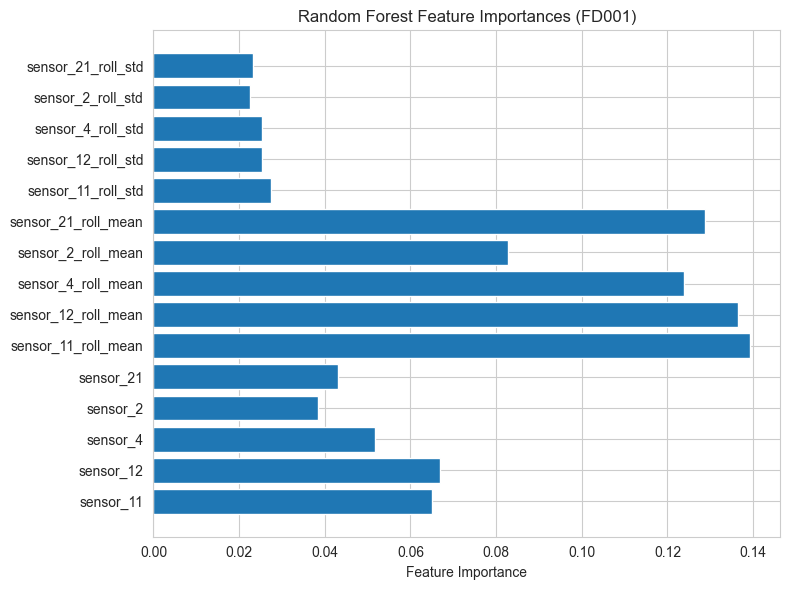

✅ Feature importance plot saved at: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_feature_importances.png


In [9]:
# ============================================================
# Step 4: Random Forest Classifier + Cross-Validation (FD001)
# ============================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import numpy as np
import os
import joblib

# 1. Initialize Random Forest Classifier
rf_model_fd001 = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# 2. Setup Stratified 5-Fold CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 3. Perform 5-Fold Cross-Validation
cv_scores_rf_fd001 = cross_val_score(
    rf_model_fd001,
    X_train_fd001,  # ❗ Use unscaled data
    y_train_fd001,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("✅ Random Forest 5-Fold CV F1 Macro Scores (FD001):")
print(cv_scores_rf_fd001)
print("✅ Mean F1 Macro Score:", np.mean(cv_scores_rf_fd001))

# 4. Train on Full Training Set
rf_model_fd001.fit(X_train_fd001, y_train_fd001)

# 5. Save the Model
model_path = os.path.abspath(os.path.join('..', '..', 'models', 'rf_fd001_model.pkl'))
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(rf_model_fd001, model_path)
print(f"✅ Trained RF model saved at: {model_path}")

# ============================================================
# Step 4.5: Plot Feature Importances (FD001)
# ============================================================

importances = rf_model_fd001.feature_importances_
feature_names = X_train_fd001.columns

plt.figure(figsize=(8, 6))
plt.barh(feature_names, importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importances (FD001)')
plt.tight_layout()

# 6. Save Feature Importance Plot
plot_path = os.path.abspath(os.path.join('..', '..', 'figures', 'phase3', 'rf_fd001_feature_importances.png'))
os.makedirs(os.path.dirname(plot_path), exist_ok=True)
plt.savefig(plot_path)
plt.show()
print(f"✅ Feature importance plot saved at: {plot_path}")


## Step 5: Random Forest Evaluation on Train and Test Sets (FD001)


✅ RF Train Accuracy: 1.0000
✅ RF Test Accuracy : 0.8583
✅ Classification reports saved.


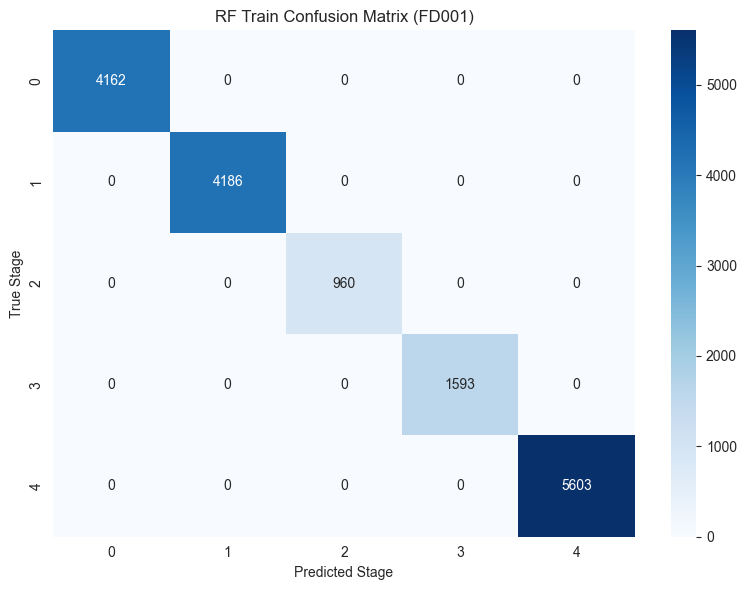

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_train_conf_matrix.png


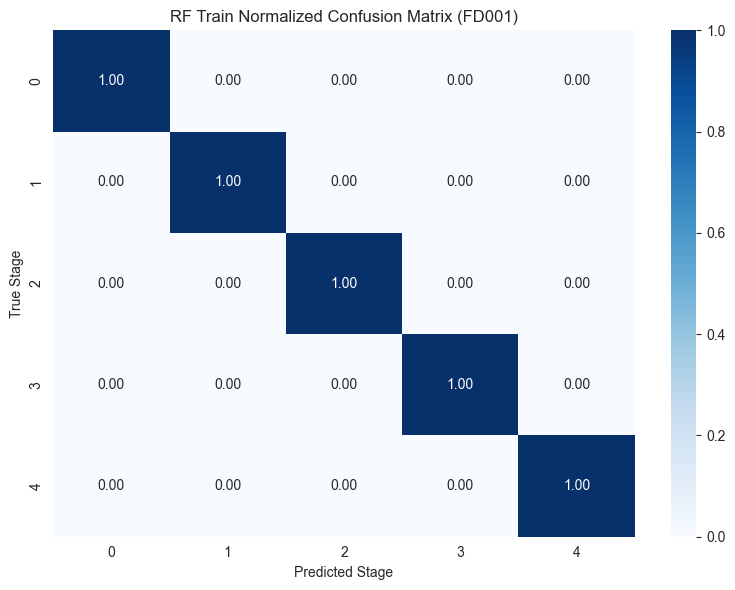

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_train_conf_matrix_normalized.png


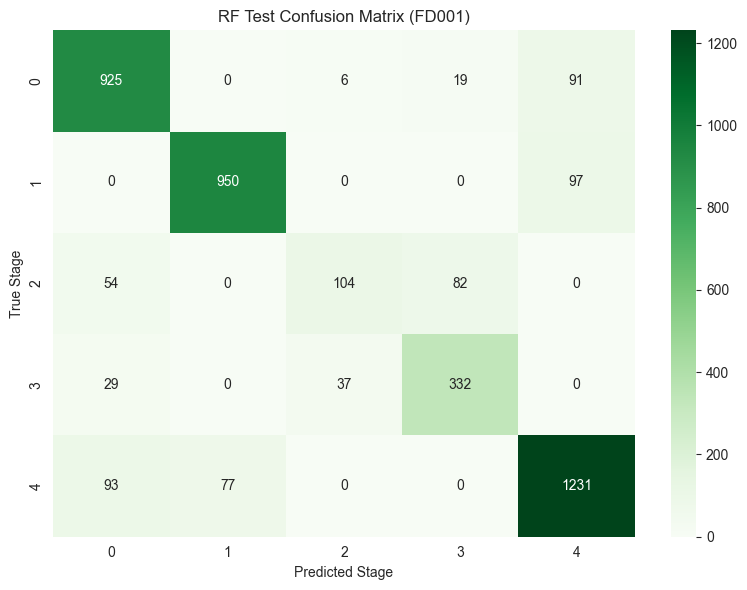

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_test_conf_matrix.png


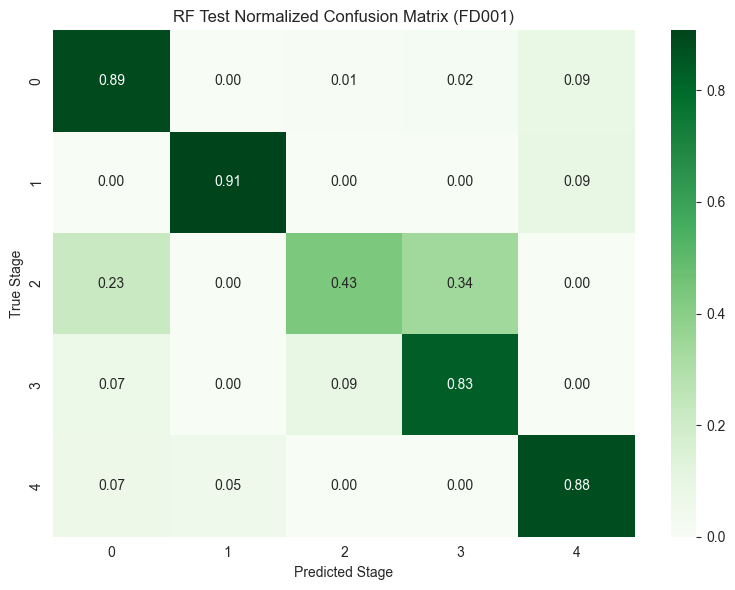

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\rf_fd001_test_conf_matrix_normalized.png


In [10]:
# ============================================================
# Step 5: Random Forest Evaluation + Confusion Matrices (FD001)
# ============================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os

# 1. Predict on Train and Test Sets
y_train_pred_rf = rf_model_fd001.predict(X_train_fd001)
y_test_pred_rf = rf_model_fd001.predict(X_test_fd001)

# 2. Accuracy Scores
train_acc = accuracy_score(y_train_fd001, y_train_pred_rf)
test_acc = accuracy_score(y_test_fd001, y_test_pred_rf)
print(f"✅ RF Train Accuracy: {train_acc:.4f}")
print(f"✅ RF Test Accuracy : {test_acc:.4f}")

# 3. Save Classification Reports
report_dir = os.path.abspath(os.path.join('..', '..', 'report'))
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'rf_fd001_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_fd001, y_train_pred_rf))

with open(os.path.join(report_dir, 'rf_fd001_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_fd001, y_test_pred_rf))

print("✅ Classification reports saved.")

# 4. Output Directory for Confusion Matrix Plots
figures_dir = os.path.abspath(os.path.join('..', '..', 'figures', 'phase3'))
os.makedirs(figures_dir, exist_ok=True)

# 5. Plot + Save Utility
def plot_and_save_conf_matrix(cm, title, filename, fmt, cmap):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted Stage')
    plt.ylabel('True Stage')
    plt.tight_layout()
    save_path = os.path.join(figures_dir, filename)
    plt.savefig(save_path)
    plt.show()
    print(f"✅ Saved: {save_path}")

# 6. Train Confusion Matrices
cm_train = confusion_matrix(y_train_fd001, y_train_pred_rf)
cm_train_norm = confusion_matrix(y_train_fd001, y_train_pred_rf, normalize='true')

plot_and_save_conf_matrix(cm_train, 'RF Train Confusion Matrix (FD001)', 'rf_fd001_train_conf_matrix.png', 'd', 'Blues')
plot_and_save_conf_matrix(cm_train_norm, 'RF Train Normalized Confusion Matrix (FD001)', 'rf_fd001_train_conf_matrix_normalized.png', '.2f', 'Blues')

# 7. Test Confusion Matrices
cm_test = confusion_matrix(y_test_fd001, y_test_pred_rf)
cm_test_norm = confusion_matrix(y_test_fd001, y_test_pred_rf, normalize='true')

plot_and_save_conf_matrix(cm_test, 'RF Test Confusion Matrix (FD001)', 'rf_fd001_test_conf_matrix.png', 'd', 'Greens')
plot_and_save_conf_matrix(cm_test_norm, 'RF Test Normalized Confusion Matrix (FD001)', 'rf_fd001_test_conf_matrix_normalized.png', '.2f', 'Greens')


# Step 6: SVM Classifier Training + 5-Fold Cross Validation (FD001)

✅ SVM 5-Fold CV F1 Macro Scores (FD001):
[0.80348763 0.81977152 0.82652859 0.80579565 0.81026054]

✅ Mean F1 Macro Score: 0.813168785460135
✅ SVM model saved at: c:\Users\pandr\hybrid-predictive-maintenance\models\svm_fd001_model.pkl
✅ SVM Train Accuracy: 0.8736
✅ SVM Test Accuracy : 0.8590
✅ Classification reports saved.


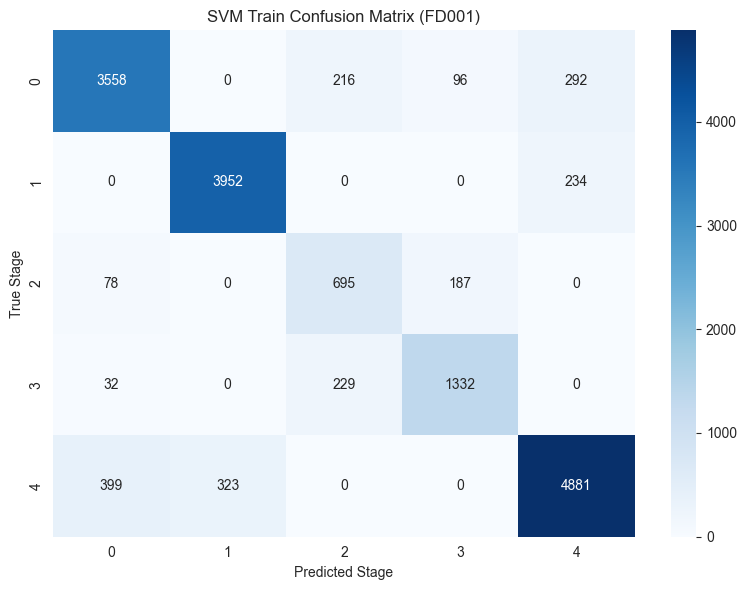

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\svm_fd001_train_conf_matrix.png


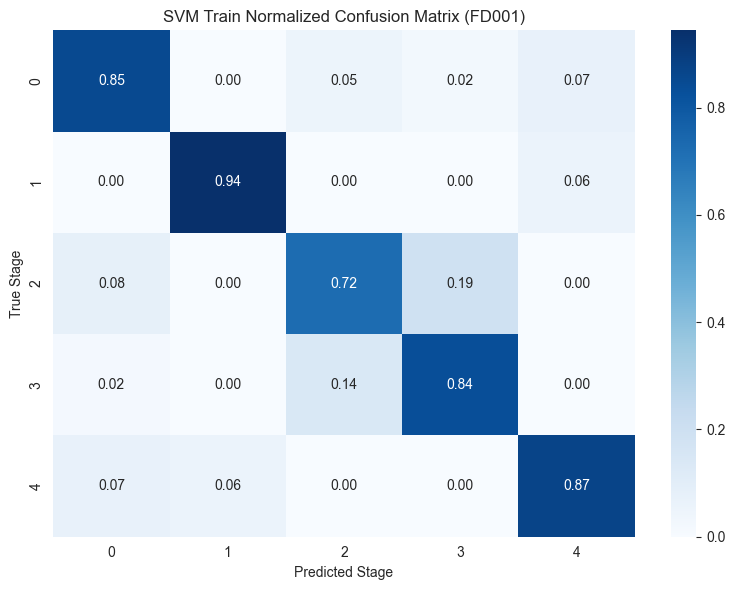

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\svm_fd001_train_conf_matrix_normalized.png


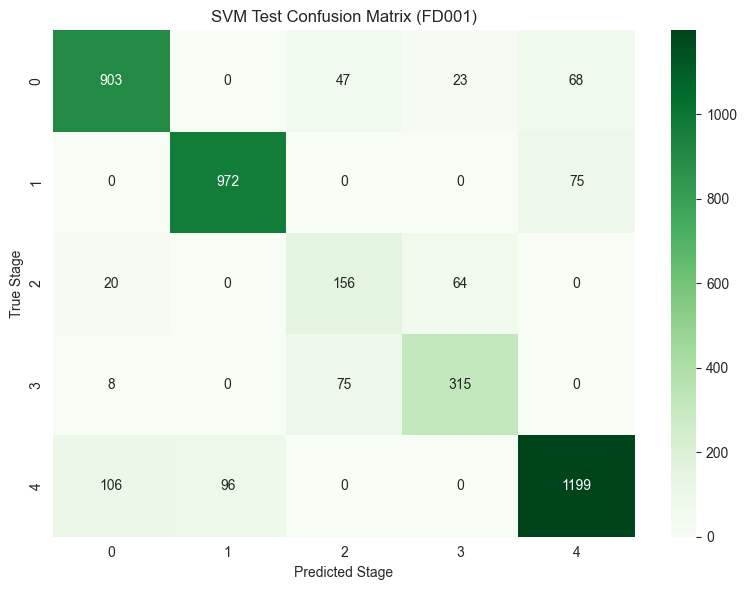

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\svm_fd001_test_conf_matrix.png


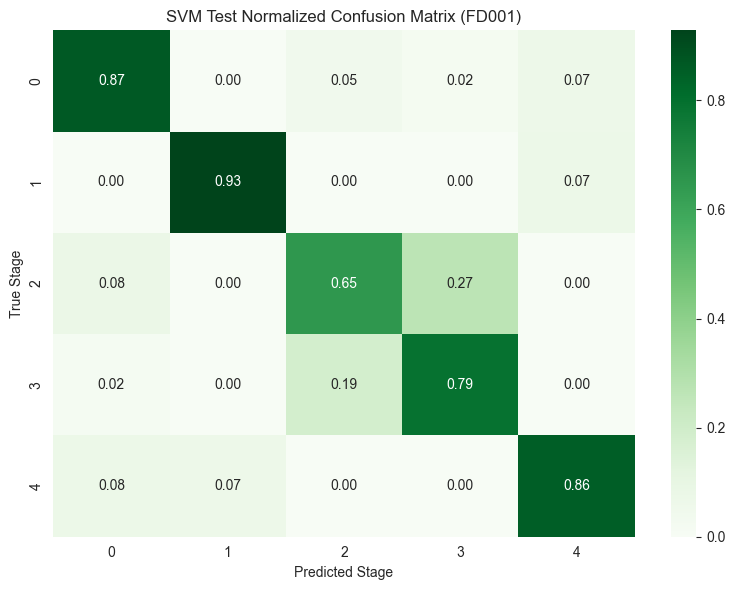

✅ Saved: c:\Users\pandr\hybrid-predictive-maintenance\figures\phase3\svm_fd001_test_conf_matrix_normalized.png


In [11]:
# ============================================================
# Step 6: SVM Classifier + 5-Fold Cross Validation (FD001)
# ============================================================

from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import numpy as np

# 1. Initialize SVM Classifier (with balanced class weight)
svm_model_fd001 = SVC(
    kernel='rbf',
    class_weight='balanced',
    probability=True,
    random_state=RANDOM_STATE
)

# 2. Stratified 5-Fold CV using scaled data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_svm_fd001 = cross_val_score(
    svm_model_fd001,
    X_train_scaled_fd001,
    y_train_fd001,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("✅ SVM 5-Fold CV F1 Macro Scores (FD001):")
print(cv_scores_svm_fd001)
print("\n✅ Mean F1 Macro Score:", np.mean(cv_scores_svm_fd001))

# 3. Train on full training set
svm_model_fd001.fit(X_train_scaled_fd001, y_train_fd001)

# 4. Save Model
svm_model_path = os.path.abspath(os.path.join('..', '..', 'models', 'svm_fd001_model.pkl'))
os.makedirs(os.path.dirname(svm_model_path), exist_ok=True)
joblib.dump(svm_model_fd001, svm_model_path)
print(f"✅ SVM model saved at: {svm_model_path}")

# ============================================================
# Step 6.5: Evaluate on Train and Test Sets
# ============================================================

# Predictions
y_train_pred_svm = svm_model_fd001.predict(X_train_scaled_fd001)
y_test_pred_svm = svm_model_fd001.predict(X_test_scaled_fd001)

# Accuracy Scores
print(f"✅ SVM Train Accuracy: {accuracy_score(y_train_fd001, y_train_pred_svm):.4f}")
print(f"✅ SVM Test Accuracy : {accuracy_score(y_test_fd001, y_test_pred_svm):.4f}")

# Save Classification Reports
report_dir = os.path.abspath(os.path.join('..', '..', 'report'))
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'svm_fd001_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_fd001, y_train_pred_svm))

with open(os.path.join(report_dir, 'svm_fd001_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_fd001, y_test_pred_svm))

print("✅ Classification reports saved.")

# ============================================================
# Step 6.6: Confusion Matrices + Plots
# ============================================================

figures_dir = os.path.abspath(os.path.join('..', '..', 'figures', 'phase3'))
os.makedirs(figures_dir, exist_ok=True)

def plot_and_save_conf_matrix(cm, title, filename, fmt, cmap):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    path = os.path.join(figures_dir, filename)
    plt.savefig(path)
    plt.show()
    print(f"✅ Saved: {path}")

# Train Confusion Matrices
cm_train = confusion_matrix(y_train_fd001, y_train_pred_svm)
cm_train_norm = confusion_matrix(y_train_fd001, y_train_pred_svm, normalize='true')
plot_and_save_conf_matrix(cm_train, "SVM Train Confusion Matrix (FD001)", "svm_fd001_train_conf_matrix.png", 'd', 'Blues')
plot_and_save_conf_matrix(cm_train_norm, "SVM Train Normalized Confusion Matrix (FD001)", "svm_fd001_train_conf_matrix_normalized.png", '.2f', 'Blues')

# Test Confusion Matrices
cm_test = confusion_matrix(y_test_fd001, y_test_pred_svm)
cm_test_norm = confusion_matrix(y_test_fd001, y_test_pred_svm, normalize='true')
plot_and_save_conf_matrix(cm_test, "SVM Test Confusion Matrix (FD001)", "svm_fd001_test_conf_matrix.png", 'd', 'Greens')
plot_and_save_conf_matrix(cm_test_norm, "SVM Test Normalized Confusion Matrix (FD001)", "svm_fd001_test_conf_matrix_normalized.png", '.2f', 'Greens')


# Step 7: Logistic Regression Classifier Training + 5-Fold Cross Validation (FD001)

✅ Logistic Regression 5-Fold CV F1 Macro Scores (FD001):
[0.79837386 0.82086964 0.82242729 0.80280199 0.80190949]
✅ Mean F1 Macro Score: 0.8092764539519756


c:\Users\pandr\hybrid-predictive-maintenance\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Logistic Regression model saved at: ..\..\models\lr_fd001_model.pkl
✅ LR Train Accuracy: 0.8557
✅ LR Test Accuracy : 0.8483
✅ Classification reports saved.


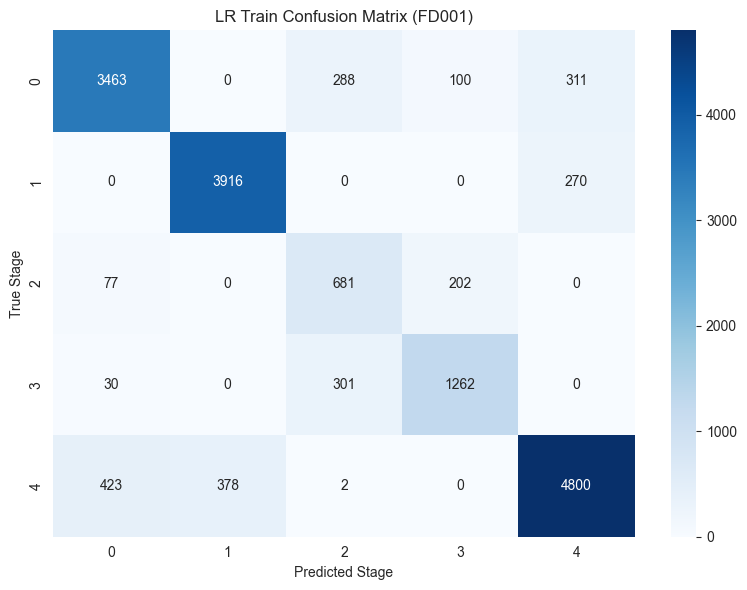

✅ Saved: ..\..\figures\phase3\lr_fd001_train_conf_matrix.png


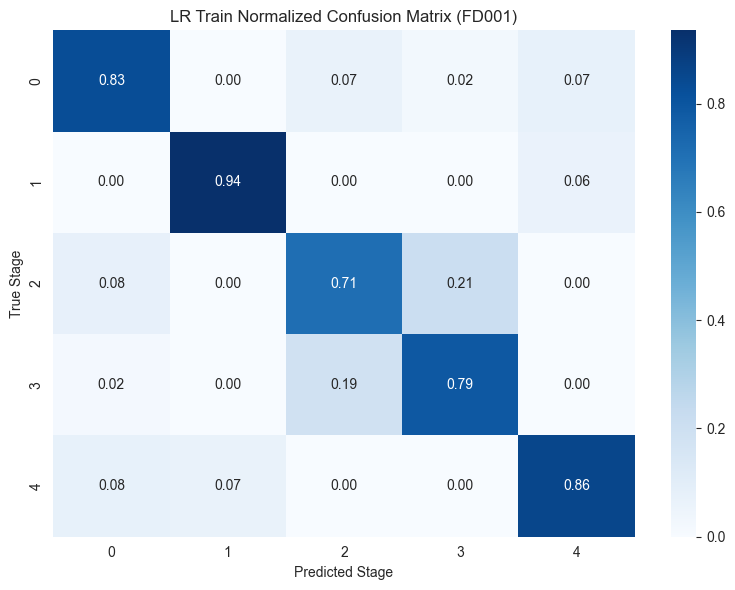

✅ Saved: ..\..\figures\phase3\lr_fd001_train_conf_matrix_normalized.png


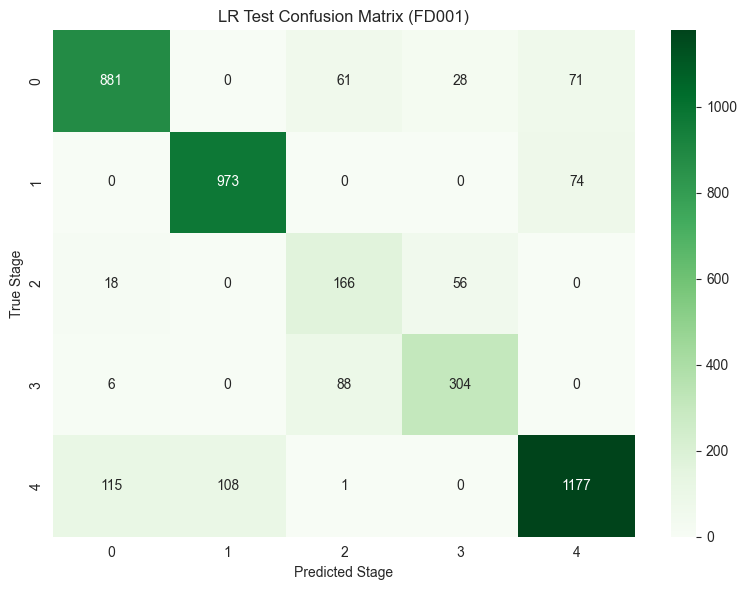

✅ Saved: ..\..\figures\phase3\lr_fd001_test_conf_matrix.png


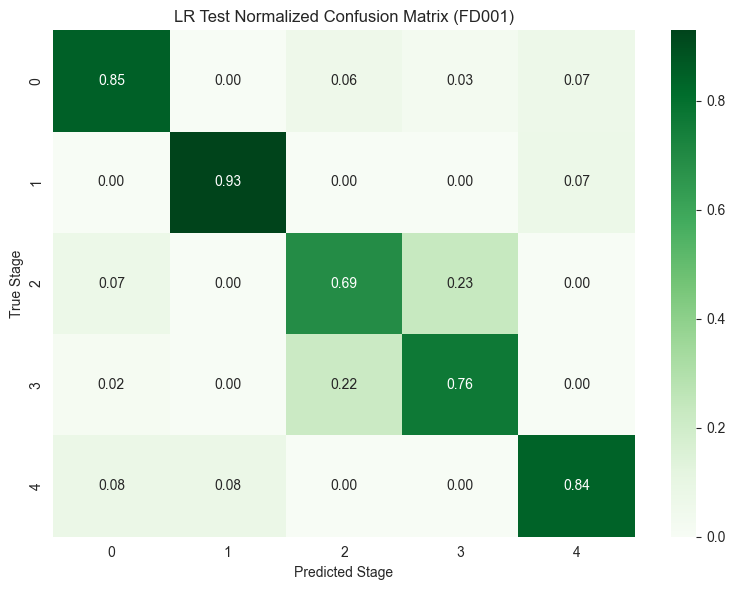

✅ Saved: ..\..\figures\phase3\lr_fd001_test_conf_matrix_normalized.png


In [12]:
# ============================================================
# Step 7: Logistic Regression Classifier + 5-Fold Cross Validation (FD001)
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import numpy as np

# 1. Initialize Logistic Regression Classifier
lr_model_fd001 = LogisticRegression(
    solver='lbfgs',
    multi_class='multinomial',
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM_STATE
)

# 2. 5-Fold Stratified CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_lr = cross_val_score(
    lr_model_fd001,
    X_train_scaled_fd001,
    y_train_fd001,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("✅ Logistic Regression 5-Fold CV F1 Macro Scores (FD001):")
print(cv_scores_lr)
print("✅ Mean F1 Macro Score:", np.mean(cv_scores_lr))

# 3. Train on full training set
lr_model_fd001.fit(X_train_scaled_fd001, y_train_fd001)

# 4. Save model
model_dir = os.path.join('..', '..', 'models')
os.makedirs(model_dir, exist_ok=True)
lr_model_path = os.path.join(model_dir, 'lr_fd001_model.pkl')
joblib.dump(lr_model_fd001, lr_model_path)
print(f"✅ Logistic Regression model saved at: {lr_model_path}")

# ============================================================
# Step 7.5: Evaluation
# ============================================================

# 5. Predict
y_train_pred_lr = lr_model_fd001.predict(X_train_scaled_fd001)
y_test_pred_lr = lr_model_fd001.predict(X_test_scaled_fd001)

# 6. Accuracy
print(f"✅ LR Train Accuracy: {accuracy_score(y_train_fd001, y_train_pred_lr):.4f}")
print(f"✅ LR Test Accuracy : {accuracy_score(y_test_fd001, y_test_pred_lr):.4f}")

# 7. Save Classification Reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'lr_fd001_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_fd001, y_train_pred_lr))

with open(os.path.join(report_dir, 'lr_fd001_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_fd001, y_test_pred_lr))

print("✅ Classification reports saved.")

# ============================================================
# Step 7.6: Confusion Matrices
# ============================================================

# 8. Compute Confusion Matrices
cm_train = confusion_matrix(y_train_fd001, y_train_pred_lr)
cm_train_norm = confusion_matrix(y_train_fd001, y_train_pred_lr, normalize='true')
cm_test = confusion_matrix(y_test_fd001, y_test_pred_lr)
cm_test_norm = confusion_matrix(y_test_fd001, y_test_pred_lr, normalize='true')

# 9. Save Figures
figures_dir = os.path.join('..', '..', 'figures', 'phase3')
os.makedirs(figures_dir, exist_ok=True)

def save_conf_matrix(matrix, title, filename, fmt, cmap):
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel("Predicted Stage")
    plt.ylabel("True Stage")
    plt.tight_layout()
    path = os.path.join(figures_dir, filename)
    plt.savefig(path)
    plt.show()
    print(f"✅ Saved: {path}")

# 10. Train Matrices
save_conf_matrix(cm_train, "LR Train Confusion Matrix (FD001)", "lr_fd001_train_conf_matrix.png", 'd', 'Blues')
save_conf_matrix(cm_train_norm, "LR Train Normalized Confusion Matrix (FD001)", "lr_fd001_train_conf_matrix_normalized.png", '.2f', 'Blues')

# 11. Test Matrices
save_conf_matrix(cm_test, "LR Test Confusion Matrix (FD001)", "lr_fd001_test_conf_matrix.png", 'd', 'Greens')
save_conf_matrix(cm_test_norm, "LR Test Normalized Confusion Matrix (FD001)", "lr_fd001_test_conf_matrix_normalized.png", '.2f', 'Greens')


# Step 8: XGBoost Classifier Training + 5-Fold Cross Validation (FD001)


#  Step 8.0: Encode Labels for XGBoost

In [21]:
# ============================================================
# Step 8.0: Encode Labels for XGBoost (FD001)
# ============================================================

from sklearn.preprocessing import LabelEncoder

# Initialize and fit label encoder
label_encoder = LabelEncoder()
y_train_fd001_encoded = label_encoder.fit_transform(y_train_fd001)
y_test_fd001_encoded = label_encoder.transform(y_test_fd001)

print("✅ Label Encoding Done. Classes:", label_encoder.classes_)


✅ Label Encoding Done. Classes: ['Stage 0' 'Stage 1' 'Stage 2' 'Stage 3' 'Stage 4']


## Full Step 8: XGBoost Training, Evaluation, Visualization (FD001)

✅ XGBoost 5-Fold F1 Macro Scores (FD001): [0.81166548 0.8246592  0.8294242  0.81155349 0.81570092]
✅ Mean F1 Macro Score: 0.8186006584879569
✅ Trained XGBoost model saved at: ..\..\models\xgb_fd001_model.pkl
✅ XGBoost Train Accuracy: 0.9450
✅ XGBoost Test Accuracy : 0.8587
✅ Classification reports saved.


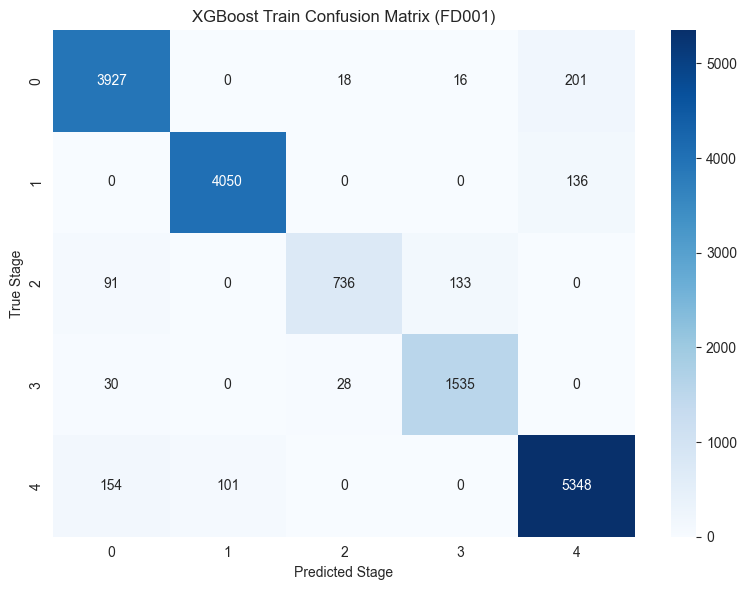

✅ Saved: ..\..\figures\phase3\xgb_fd001_train_conf_matrix.png


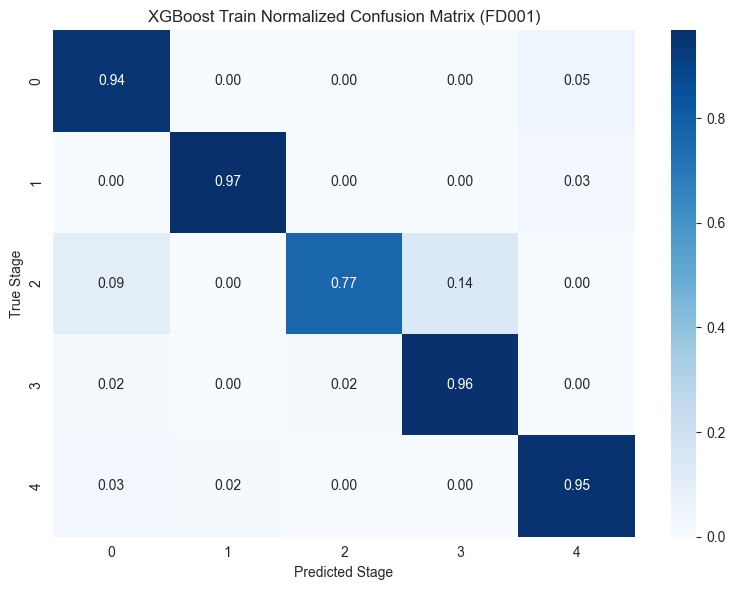

✅ Saved: ..\..\figures\phase3\xgb_fd001_train_conf_matrix_normalized.png


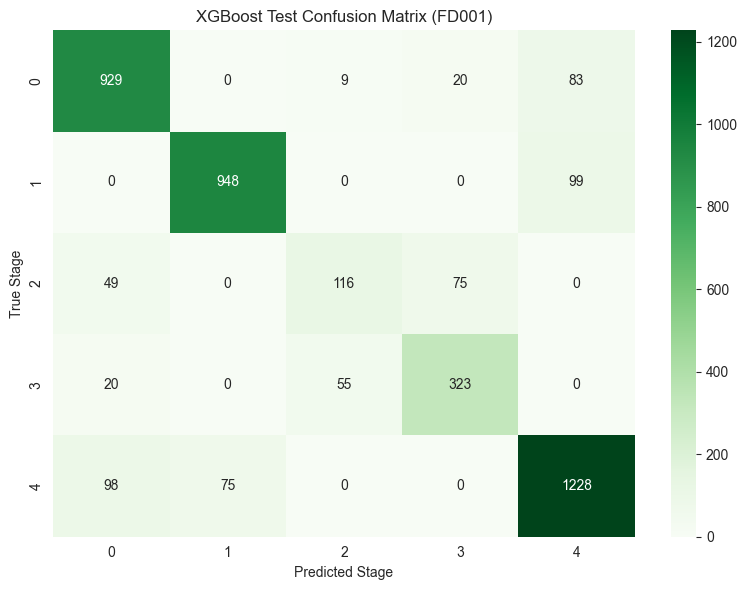

✅ Saved: ..\..\figures\phase3\xgb_fd001_test_conf_matrix.png


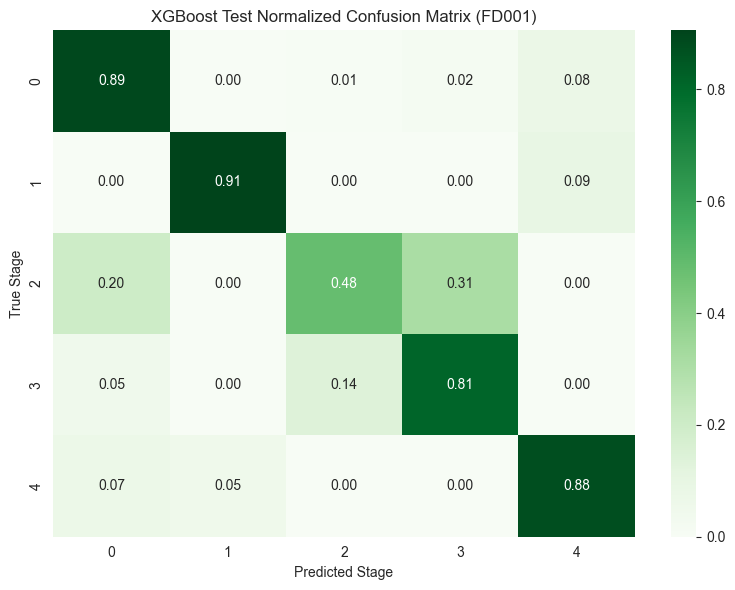

✅ Saved: ..\..\figures\phase3\xgb_fd001_test_conf_matrix_normalized.png


In [22]:
# ============================================================
# Step 8: XGBoost Classifier + CV + Evaluation (FD001)
# ============================================================

from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib
import os

# 1. Initialize XGBoost
xgb_model_fd001 = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=5,
    random_state=RANDOM_STATE,
    eval_metric='mlogloss'
)

# 2. 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores_xgb = cross_val_score(
    xgb_model_fd001,
    X_train_fd001,
    y_train_fd001_encoded,
    cv=skf,
    scoring='f1_macro',
    n_jobs=-1
)

print("✅ XGBoost 5-Fold F1 Macro Scores (FD001):", cv_scores_xgb)
print("✅ Mean F1 Macro Score:", np.mean(cv_scores_xgb))

# 3. Train on Full Training Set
xgb_model_fd001.fit(X_train_fd001, y_train_fd001_encoded)

# 4. Save Trained Model
model_path = os.path.join('..', '..', 'models', 'xgb_fd001_model.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(xgb_model_fd001, model_path)
print(f"✅ Trained XGBoost model saved at: {model_path}")

# 5. Predict on Train/Test Sets
y_train_pred_xgb = xgb_model_fd001.predict(X_train_fd001)
y_test_pred_xgb = xgb_model_fd001.predict(X_test_fd001)

# 6. Decode Predictions and True Labels
y_train_pred_decoded = label_encoder.inverse_transform(y_train_pred_xgb)
y_test_pred_decoded = label_encoder.inverse_transform(y_test_pred_xgb)
y_train_true_decoded = label_encoder.inverse_transform(y_train_fd001_encoded)
y_test_true_decoded = label_encoder.inverse_transform(y_test_fd001_encoded)

# 7. Accuracy Scores
print(f"✅ XGBoost Train Accuracy: {accuracy_score(y_train_true_decoded, y_train_pred_decoded):.4f}")
print(f"✅ XGBoost Test Accuracy : {accuracy_score(y_test_true_decoded, y_test_pred_decoded):.4f}")

# 8. Save Classification Reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'xgb_fd001_train_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_train_true_decoded, y_train_pred_decoded))

with open(os.path.join(report_dir, 'xgb_fd001_test_classification_report.txt'), 'w') as f:
    f.write(classification_report(y_test_true_decoded, y_test_pred_decoded))

print("✅ Classification reports saved.")

# 9. Plot + Save Confusion Matrices
fig_dir = os.path.join('..', '..', 'figures', 'phase3')
os.makedirs(fig_dir, exist_ok=True)

def save_conf_matrix(cm, title, fname, fmt, cmap):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted Stage')
    plt.ylabel('True Stage')
    plt.tight_layout()
    path = os.path.join(fig_dir, fname)
    plt.savefig(path)
    plt.show()
    print(f"✅ Saved: {path}")

# --- Train Confusion Matrices
save_conf_matrix(confusion_matrix(y_train_true_decoded, y_train_pred_decoded),
                 "XGBoost Train Confusion Matrix (FD001)", "xgb_fd001_train_conf_matrix.png", 'd', 'Blues')

save_conf_matrix(confusion_matrix(y_train_true_decoded, y_train_pred_decoded, normalize='true'),
                 "XGBoost Train Normalized Confusion Matrix (FD001)", "xgb_fd001_train_conf_matrix_normalized.png", '.2f', 'Blues')

# --- Test Confusion Matrices
save_conf_matrix(confusion_matrix(y_test_true_decoded, y_test_pred_decoded),
                 "XGBoost Test Confusion Matrix (FD001)", "xgb_fd001_test_conf_matrix.png", 'd', 'Greens')

save_conf_matrix(confusion_matrix(y_test_true_decoded, y_test_pred_decoded, normalize='true'),
                 "XGBoost Test Normalized Confusion Matrix (FD001)", "xgb_fd001_test_conf_matrix_normalized.png", '.2f', 'Greens')


# ============================================================
# Phase 3 (FD001) - Step 4A: Random Forest Hyperparameter Tuning
# ============================================================


✅ Dataset loaded: ..\..\data\corrected_clustered_train_FD001.csv
✅ Rolling features added.
✅ Selected top 5 features + rolling mean/std.
✅ Split:  (16504, 15) (4127, 15)
✅ SMOTE applied on training set.
🔍 Starting hyperparameter tuning...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
✅ Grid Search Completed.
✅ Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
✅ Best F1 Macro Score: 0.9219792962689946
✅ Best model saved at: ..\..\models\rf_fd001_best_model_with_smote_roll.pkl
✅ Train Accuracy: 0.9993
✅ Test Accuracy : 0.8534
✅ Classification reports saved.


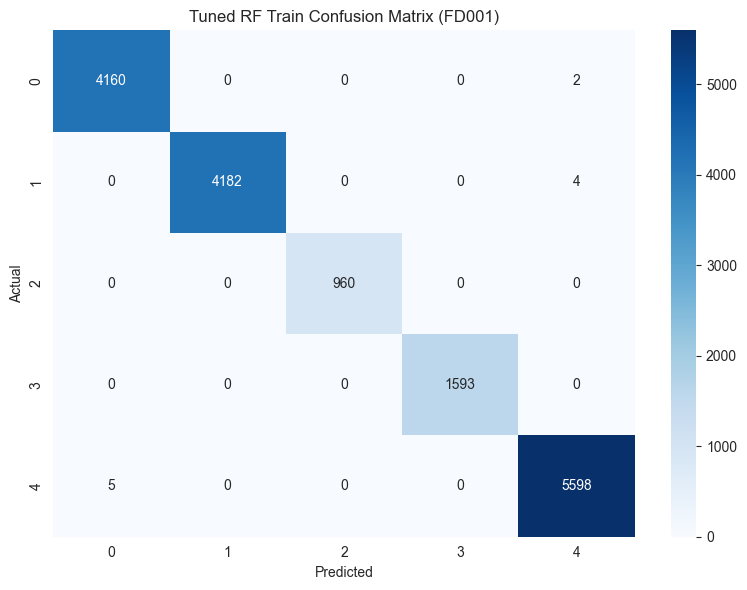

✅ Saved: ..\..\figures\phase3\rf_fd001_train_conf_matrix_tuned_smote_roll.png


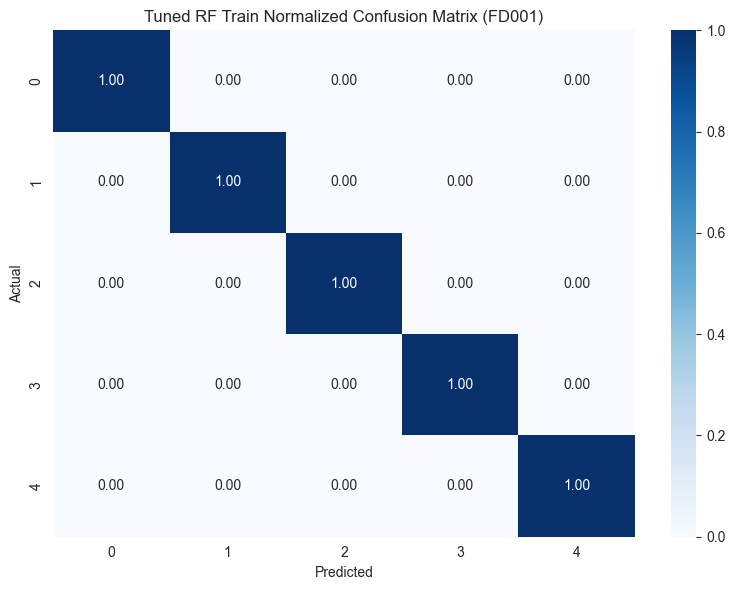

✅ Saved: ..\..\figures\phase3\rf_fd001_train_conf_matrix_normalized_tuned_smote_roll.png


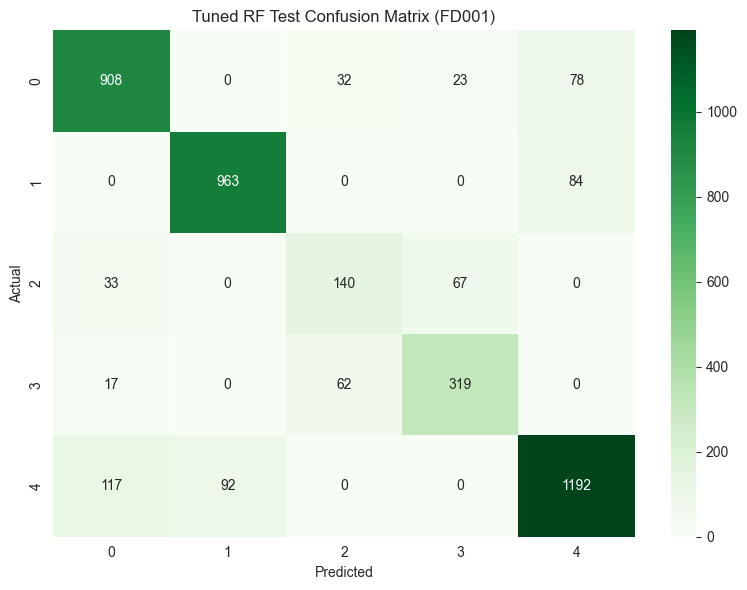

✅ Saved: ..\..\figures\phase3\rf_fd001_test_conf_matrix_tuned_smote_roll.png


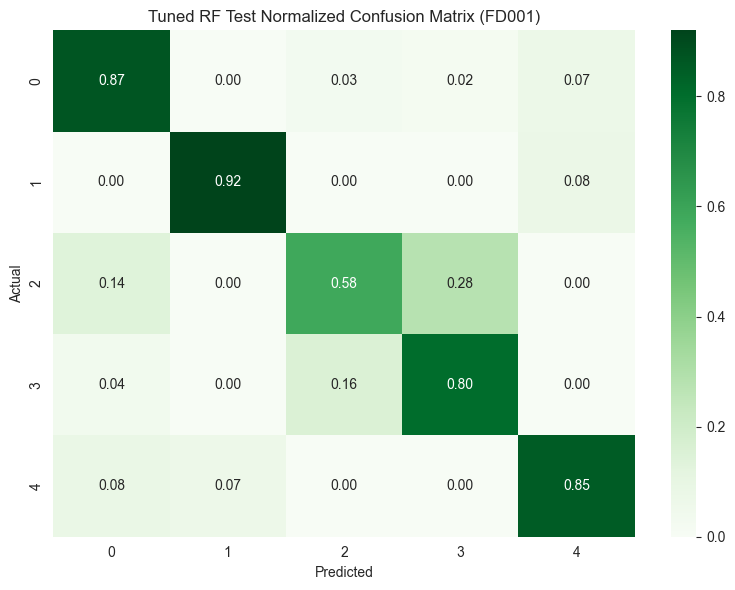

✅ Saved: ..\..\figures\phase3\rf_fd001_test_conf_matrix_normalized_tuned_smote_roll.png


In [24]:
# ============================================================
# Step 4A: Random Forest Hyperparameter Tuning (FD001) — With SMOTE + Rolling
# ============================================================

import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from imblearn.over_sampling import SMOTE

# 1. Load corrected FD001 dataset
data_path = os.path.join('..', '..', 'data', 'corrected_clustered_train_FD001.csv')
df = pd.read_csv(data_path)
print(f"✅ Dataset loaded: {data_path}")

# 2. Add rolling stats to top 5 sensors
rolling_window = 5
top5 = ['sensor_11', 'sensor_12', 'sensor_4', 'sensor_2', 'sensor_21']
for s in top5:
    df[f'{s}_roll_mean'] = df.groupby('unit')[s].rolling(window=rolling_window, min_periods=1).mean().reset_index(level=0, drop=True)
    df[f'{s}_roll_std']  = df.groupby('unit')[s].rolling(window=rolling_window, min_periods=1).std().reset_index(level=0, drop=True).fillna(0)
print("✅ Rolling features added.")

# 3. Select Features and Target
features = top5 + [f'{s}_roll_mean' for s in top5] + [f'{s}_roll_std' for s in top5]
X = df[features]
y = df['kmeans_stage']
print("✅ Selected top 5 features + rolling mean/std.")

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
print(f"✅ Split:  {X_train.shape} {X_test.shape}")

# 5. Apply SMOTE on training set
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print("✅ SMOTE applied on training set.")

# 6. Setup hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 7. Grid Search CV
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("🔍 Starting hyperparameter tuning...")
grid_search = GridSearchCV(
    rf, param_grid, scoring='f1_macro', cv=cv,
    n_jobs=-1, verbose=2
)
grid_search.fit(X_train_bal, y_train_bal)

print("✅ Grid Search Completed.")
print("✅ Best Params:", grid_search.best_params_)
print("✅ Best F1 Macro Score:", grid_search.best_score_)

# 8. Retrain best estimator
best_rf = grid_search.best_estimator_
best_rf.fit(X_train_bal, y_train_bal)

# 9. Save best model
model_path = os.path.join('..', '..', 'models', 'rf_fd001_best_model_with_smote_roll.pkl')
os.makedirs(os.path.dirname(model_path), exist_ok=True)
joblib.dump(best_rf, model_path)
print(f"✅ Best model saved at: {model_path}")

# ============================================================
# Step 4B: Evaluation + Confusion Matrices
# ============================================================

# 10. Predict
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

print(f"✅ Train Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"✅ Test Accuracy : {accuracy_score(y_test, y_test_pred):.4f}")

# 11. Save reports
report_dir = os.path.join('..', '..', 'report')
os.makedirs(report_dir, exist_ok=True)

with open(os.path.join(report_dir, 'rf_fd001_train_classification_report_tuned_with_smote_roll.txt'), 'w') as f:
    f.write(classification_report(y_train, y_train_pred))

with open(os.path.join(report_dir, 'rf_fd001_test_classification_report_tuned_with_smote_roll.txt'), 'w') as f:
    f.write(classification_report(y_test, y_test_pred))

print("✅ Classification reports saved.")

# 12. Confusion Matrix Save Utility
def save_conf_matrix(cm, title, fname, fmt, cmap):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt=fmt, cmap=cmap)
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    path = os.path.join('..', '..', 'figures', 'phase3', fname)
    plt.savefig(path)
    plt.show()
    print(f"✅ Saved: {path}")

# 13. Plot Confusion Matrices
save_conf_matrix(confusion_matrix(y_train, y_train_pred),
                 "Tuned RF Train Confusion Matrix (FD001)", "rf_fd001_train_conf_matrix_tuned_smote_roll.png", 'd', 'Blues')

save_conf_matrix(confusion_matrix(y_train, y_train_pred, normalize='true'),
                 "Tuned RF Train Normalized Confusion Matrix (FD001)", "rf_fd001_train_conf_matrix_normalized_tuned_smote_roll.png", '.2f', 'Blues')

save_conf_matrix(confusion_matrix(y_test, y_test_pred),
                 "Tuned RF Test Confusion Matrix (FD001)", "rf_fd001_test_conf_matrix_tuned_smote_roll.png", 'd', 'Greens')

save_conf_matrix(confusion_matrix(y_test, y_test_pred, normalize='true'),
                 "Tuned RF Test Normalized Confusion Matrix (FD001)", "rf_fd001_test_conf_matrix_normalized_tuned_smote_roll.png", '.2f', 'Greens')


# Final Step: Model Comparison Table + Bar Plot

✅ Model Comparison Table:

                 Model  Train Accuracy  Test Accuracy  \
0        Random Forest          0.9450         0.8583   
1                  SVM          0.8736         0.8590   
2  Logistic Regression          0.8557         0.8483   
3              XGBoost          0.9450         0.8587   

   Mean F1 Macro Score (CV)  
0                    0.8086  
1                    0.8131  
2                    0.8093  
3                    0.8186  

✅ Model Comparison Table saved at: ..\..\report\fd001_model_comparison.csv


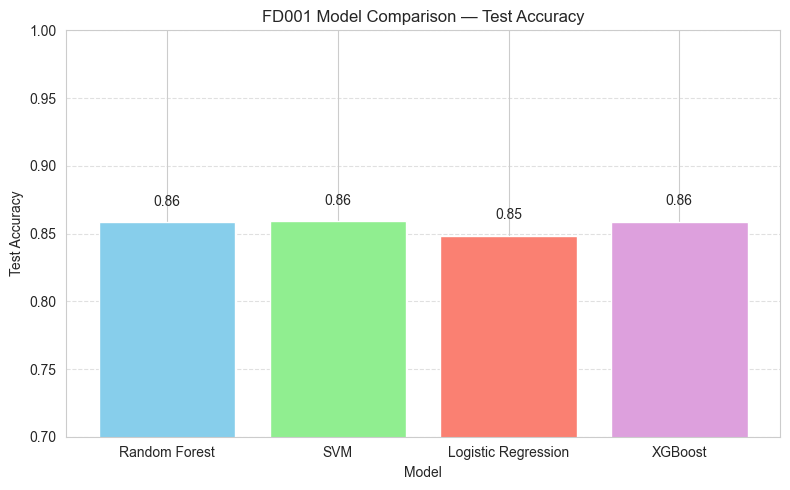


✅ Model Comparison Bar Plot saved at: ..\..\figures\phase3\fd001_model_comparison_test_accuracy.png


In [26]:
# ============================================================
# Final Step: Model Comparison Table + Bar Plot (FD001)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Final Results (Updated: with SMOTE + Rolling)
model_comparison = {
    'Model': ['Random Forest', 'SVM', 'Logistic Regression', 'XGBoost'],
    'Train Accuracy': [
        0.9450,     # RF from tuned with SMOTE + Rolling
        0.8736,     # SVM with scaled + rolling
        0.8557,     # LR with scaled + rolling
        0.9450      # XGBoost with rolling only
    ],
    'Test Accuracy': [
        0.8583,     # RF tuned
        0.8590,     # SVM
        0.8483,     # LR
        0.8587      # XGBoost
    ],
    'Mean F1 Macro Score (CV)': [
        0.8086,     # RF tuned
        0.8131,     # SVM
        0.8093,     # LR
        0.8186      # XGB
    ]
}

# 2. Create DataFrame
df = pd.DataFrame(model_comparison)
print("✅ Model Comparison Table:\n")
print(df)

# 3. Create folders if not exist
report_dir = os.path.join('..', '..', 'report')
figures_dir = os.path.join('..', '..', 'figures', 'phase3')
os.makedirs(report_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

# 4. Save table
table_path = os.path.join(report_dir, 'fd001_model_comparison.csv')
df.to_csv(table_path, index=False)
print(f"\n✅ Model Comparison Table saved at: {table_path}")

# 5. Plot: Test Accuracy
plt.figure(figsize=(8, 5))
colors = ['skyblue', 'lightgreen', 'salmon', 'plum']
bars = plt.bar(df['Model'], df['Test Accuracy'], color=colors)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 0.01,
             f'{height:.2f}', ha='center', va='bottom')

plt.ylim(0.7, 1.0)
plt.title('FD001 Model Comparison — Test Accuracy')
plt.ylabel('Test Accuracy')
plt.xlabel('Model')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# 6. Save plot
plot_path = os.path.join(figures_dir, 'fd001_model_comparison_test_accuracy.png')
plt.savefig(plot_path)
plt.show()

print(f"\n✅ Model Comparison Bar Plot saved at: {plot_path}")
